In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install numpy matplotlib scipy scikit-learn

import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC

In [3]:
def readBiopacResults(filename):

    f = open(filename,'r')
    temp = []
    for l in f:
        temp.append(l)
    f.close()

    result = []
    for i in range(0,len(temp)):
        q = temp[i].strip().split()
        result.append([float(i) for i in q])

    return np.array(result)

Data shape: (130960, 2)


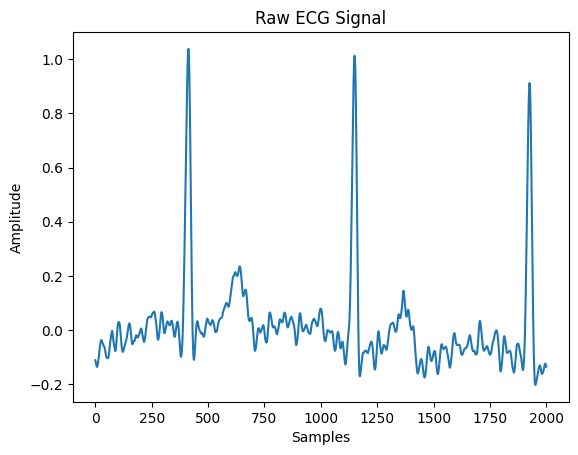

In [4]:
# CHANGE PATH if needed
file_path = '/content/drive/MyDrive/Lab03/Lab-03-L05_ayesha.txt'

results_data = readBiopacResults(file_path)

print("Data shape:", results_data.shape)

# Extract ECG (Biopac raw signal is usually column 0)
ecg = results_data[:,0]

t = np.arange(len(ecg))

# Plot raw ECG
plt.figure()
plt.plot(t[:2000], ecg[:2000])
plt.title("Raw ECG Signal")
plt.xlabel("Samples")
plt.ylabel("Amplitude")
plt.show()

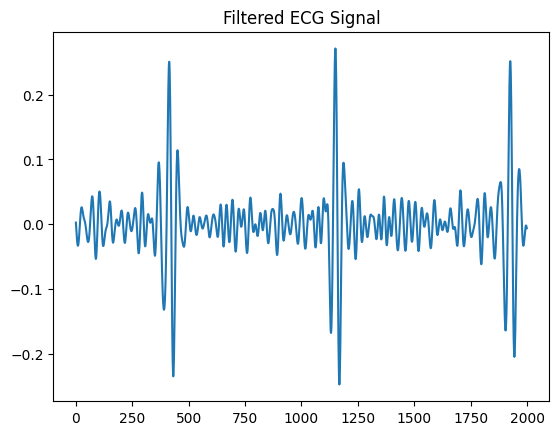

In [5]:
def bandpass(signal, fs=250, low=5, high=15):
    b, a = butter(2, [low/(fs/2), high/(fs/2)], btype='band')
    return filtfilt(b, a, signal)

filtered = bandpass(ecg)

plt.figure()
plt.plot(filtered[:2000])
plt.title("Filtered ECG Signal")
plt.show()

Number of peaks: 458


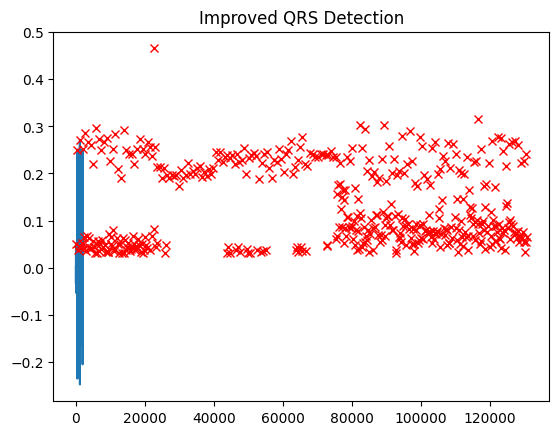

In [12]:
# 🔥 Strong threshold (KEY FIX)
threshold = np.mean(filtered) + 0.6*np.std(filtered)

peaks, _ = find_peaks(
    filtered,
    distance=150,     # prevents multiple detections per beat
    height=threshold
)

print("Number of peaks:", len(peaks))

plt.figure()
plt.plot(filtered[:2000])
plt.plot(peaks, filtered[peaks], "rx")
plt.title("Improved QRS Detection")
plt.show()

In [13]:
window_size = 100

X = []
y = []

peak_set = set(peaks)

for i in range(window_size, len(filtered)-window_size):
    segment = filtered[i-window_size:i+window_size]

    # Label 1 if near peak (±5 samples)
    label = 1 if any((i+j) in peak_set for j in range(-5,6)) else 0

    X.append(segment)
    y.append(label)

X = np.array(X)
y = np.array(y)

print("Dataset shape:", X.shape)

Dataset shape: (130760, 200)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3)

model = SVC(kernel='rbf', class_weight='balanced')
model.fit(X_train, y_train)

accuracy = model.score(X_test, y_test)
print("Model Accuracy:", accuracy)

Model Accuracy: 0.9306107882125013


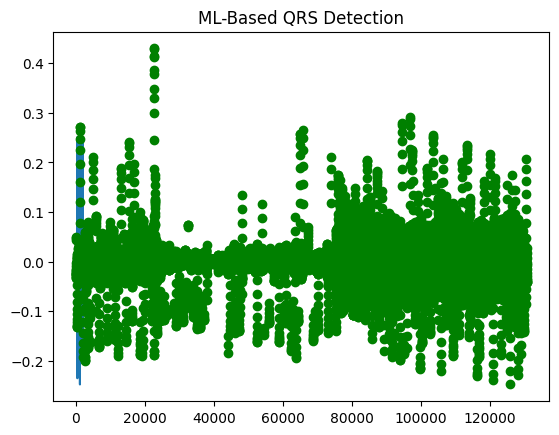

In [9]:
predictions = model.predict(X)

detected_peaks = np.where(predictions == 1)[0]

plt.figure()
plt.plot(filtered[:2000])
plt.plot(detected_peaks, filtered[detected_peaks], "go")
plt.title("ML-Based QRS Detection")
plt.show()

In [10]:
TP = np.sum((predictions == 1) & (y == 1))
FP = np.sum((predictions == 1) & (y == 0))
FN = np.sum((predictions == 0) & (y == 1))

sensitivity = TP / (TP + FN)
false_alarm = FP / (TP + FP)

print("Sensitivity (Missed Detection):", sensitivity)
print("False Alarm Rate:", false_alarm)

Sensitivity (Missed Detection): 0.6059516023544801
False Alarm Rate: 0.10984787830264212
